<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Monte_Carlo_integral_exp_x2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimación Monte Carlo de una integral

$$
I=\int_0^1 e^{x^2}\,dx
$$

por el método de Monte Carlo.

La condición de paro será que la desviación estándar del estimador sea menor que:

$$
d=0.01
$$

Además, se generarán al menos 100 valores antes de verificar la condición de paro.

## Idea del método

Sea $U$ una variable aleatoria uniforme en el intervalo $[0,1]$:

$$
U\sim U(0,1)
$$

Entonces:

$$
E\left(e^{U^2}\right)=\int_0^1 e^{x^2}\,dx
$$

Por lo tanto, si generamos $U_1,U_2,\dots,U_k$, podemos estimar la integral con:

$$
\hat I=\bar X=\frac{1}{k}\sum_{i=1}^k e^{U_i^2}
$$

donde:

$$
X_i=e^{U_i^2}
$$

La desviación estándar estimada del estimador es:

$$
\frac{S}{\sqrt{k}}
$$

donde $S$ es la desviación estándar muestral de los valores $X_1,X_2,\dots,X_k$.

El algoritmo se detiene cuando:

$$
\frac{S}{\sqrt{k}}<0.01
$$

In [22]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

## Parámetros del problema

Aquí definimos la tolerancia $d=0.01$ y el número mínimo de valores que se deben generar.

In [23]:
# Tolerancia pedida por el problema
d = 0.01

# Número mínimo de valores que se deben generar
n_min = 100

print("Tolerancia d =", d)
print("Número mínimo de valores =", n_min)

Tolerancia d = 0.01
Número mínimo de valores = 100


## Función para estimar la integral

La siguiente función aplica directamente el método Monte Carlo.

Pasos:

1. Genera variables aleatorias uniformes $U_i\sim U(0,1)$.
2. Calcula $X_i=e^{U_i^2}$.
3. Calcula la media muestral $\bar X$.
4. Calcula la desviación estándar muestral $S$.
5. Calcula la desviación estándar del estimador $S/\sqrt{k}$.
6. Se detiene cuando $S/\sqrt{k}<0.01$, pero siempre después de generar al menos 100 valores.

In [24]:
def estimar_integral_monte_carlo(d=0.01, n_min=100):

    # Lista donde guardaremos los valores X_i = exp(U_i^2)
    valores = []

    # Estas listas guardan el comportamiento de la estimación conforme aumenta k
    historial_medias = []
    historial_errores = []

    # Primero generamos al menos n_min valores
    for i in range(n_min):
        # Generamos U_i uniforme en [0,1]
        u = np.random.uniform(0, 1)

        # Calculamos X_i = exp(U_i^2)
        x = np.exp(u**2)

        # Guardamos el valor generado
        valores.append(x)

    # Calculamos las primeras cantidades con los n_min datos
    k = len(valores)
    estimacion = np.mean(valores)
    S = np.std(valores, ddof=1)  # ddof=1 indica desviación estándar muestral
    error_estandar = S / np.sqrt(k)

    historial_medias.append(estimacion)
    historial_errores.append(error_estandar)


    while error_estandar >= d:
        # Generamos un nuevo número aleatorio uniforme
        u = np.random.uniform(0, 1)

        # Calculamos el valor de la función en ese número aleatorio
        x = np.exp(u**2)

        # Agregamos el nuevo valor a la muestra
        valores.append(x)

        # Actualizamos el tamaño de la muestra
        k = len(valores)

        # Actualizamos la estimación de la integral
        estimacion = np.mean(valores)

        # Actualizamos la desviación estándar muestral
        S = np.std(valores, ddof=1)

        # Actualizamos la desviación estándar del estimador
        error_estandar = S / np.sqrt(k)

        # Guardamos los valores para graficar después
        historial_medias.append(estimacion)
        historial_errores.append(error_estandar)

    return estimacion, k, S, error_estandar, historial_medias, historial_errores

In [25]:
# Ejecutamos el método Monte Carlo
estimacion, k, S, error_estandar, historial_medias, historial_errores = estimar_integral_monte_carlo(d, n_min)

# Mostramos los resultados
print("Resultados del método Monte Carlo")
print("---------------------------------")
print("Número total de datos generados k:", k)
print("Estimación de la integral:", estimacion)
print("Desviación estándar muestral S:", S)
print("Desviación estándar del estimador S/sqrt(k):", error_estandar)
print("Tolerancia solicitada d:", d)

Resultados del método Monte Carlo
---------------------------------
Número total de datos generados k: 2297
Estimación de la integral: 1.4722542314114602
Desviación estándar muestral S: 0.4790735251074054
Desviación estándar del estimador S/sqrt(k): 0.009995894726749633
Tolerancia solicitada d: 0.01


## Comparación con un valor de referencia

La integral $\int_0^1 e^{x^2}\,dx$ no tiene una antiderivada elemental. Por eso, para comparar, calculamos un valor numérico de referencia usando integración numérica.

In [26]:


try:
    from scipy.integrate import quad
    valor_referencia, error_quad = quad(lambda x: np.exp(x**2), 0, 1)
except Exception:
    # Regla del trapecio como alternativa
    xs = np.linspace(0, 1, 1_000_001)
    ys = np.exp(xs**2)
    valor_referencia = np.trapz(ys, xs)

# Calculamos el error absoluto entre la estimación y el valor de referencia
error_absoluto = abs(estimacion - valor_referencia)

print("Valor de referencia aproximado:", valor_referencia)
print("Estimación Monte Carlo:", estimacion)
print("Error absoluto:", error_absoluto)

Valor de referencia aproximado: 1.4626517459071815
Estimación Monte Carlo: 1.4722542314114602
Error absoluto: 0.009602485504278668


## Gráfica de convergencia

La siguiente gráfica muestra cómo va cambiando la estimación conforme se generan más datos.

Se espera que la estimación se acerque al valor real aproximado cuando aumenta el número de simulaciones.

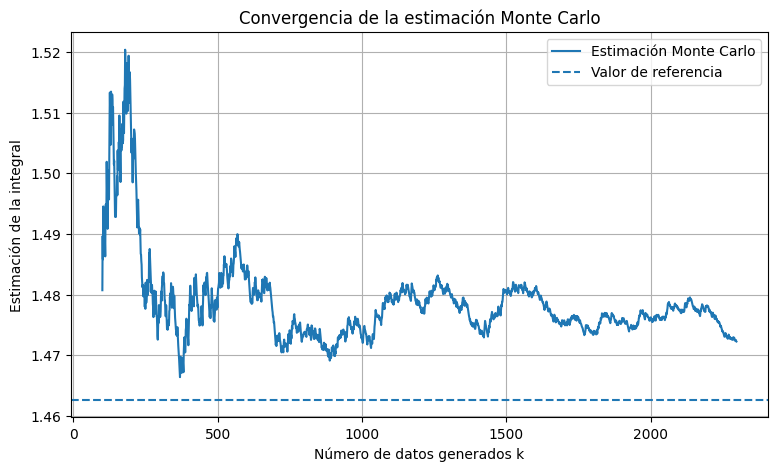

In [27]:
ks = np.arange(n_min, n_min + len(historial_medias))

plt.figure(figsize=(9, 5))
plt.plot(ks, historial_medias, label="Estimación Monte Carlo")
plt.axhline(valor_referencia, linestyle="--", label="Valor de referencia")
plt.xlabel("Número de datos generados k")
plt.ylabel("Estimación de la integral")
plt.title("Convergencia de la estimación Monte Carlo")
plt.legend()
plt.grid(True)
plt.show()

## Gráfica de la desviación estándar del estimador

Esta gráfica muestra el valor de:

$$
\frac{S}{\sqrt{k}}
$$

El algoritmo se detiene cuando esta cantidad es menor que $0.01$.

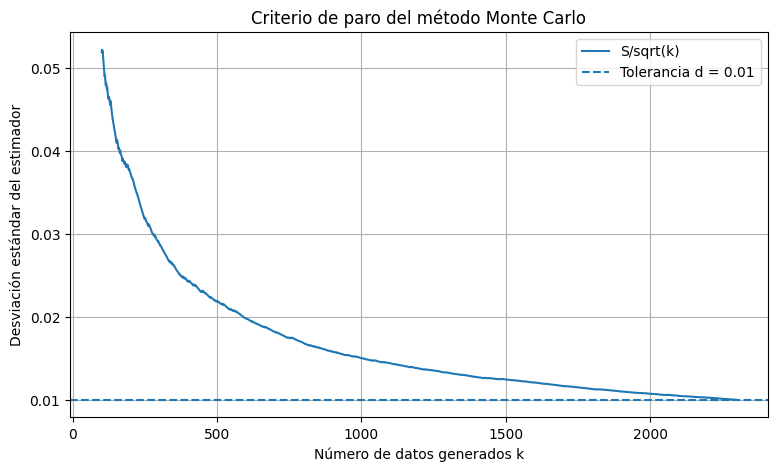

In [28]:
plt.figure(figsize=(9, 5))
plt.plot(ks, historial_errores, label="S/sqrt(k)")
plt.axhline(d, linestyle="--", label="Tolerancia d = 0.01")
plt.xlabel("Número de datos generados k")
plt.ylabel("Desviación estándar del estimador")
plt.title("Criterio de paro del método Monte Carlo")
plt.legend()
plt.grid(True)
plt.show()

## Conclusión

Se estimó la integral

$$
\int_0^1 e^{x^2}\,dx
$$

usando el método Monte Carlo. La estimación se obtiene como el promedio de los valores $e^{U_i^2}$, donde $U_i$ son variables uniformes en $[0,1]$.

El proceso se detuvo cuando la desviación estándar del estimador fue menor que $0.01$, cumpliendo la condición solicitada en la actividad.